In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt


### Задание 1

Нужно реализовать усреднение зашумленного сигнала по формуле скользящего среднего:

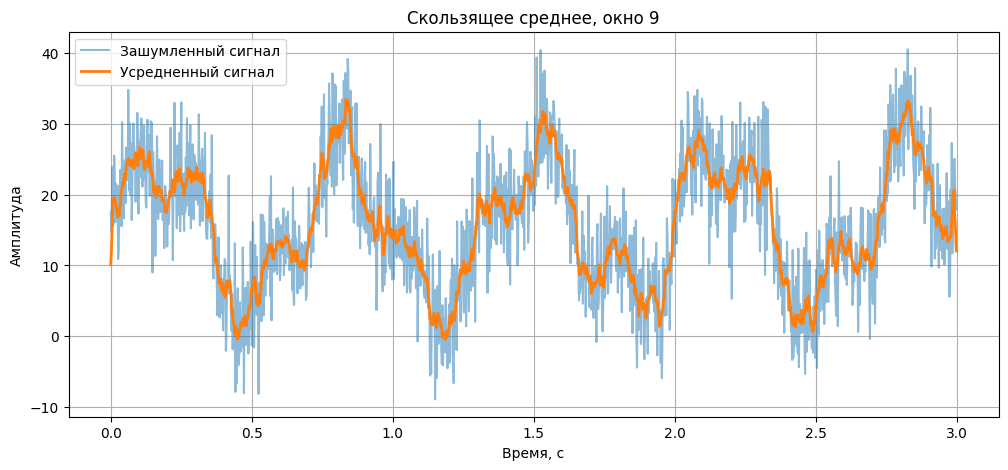

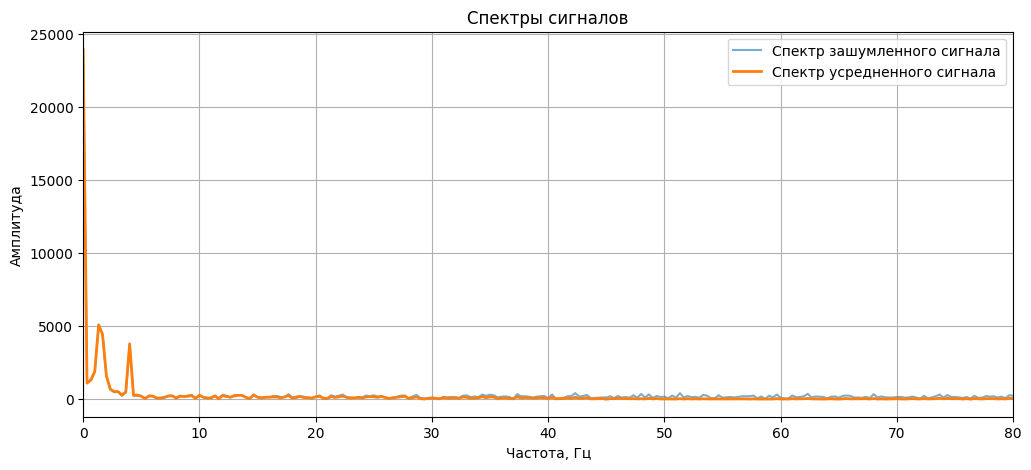

In [3]:
np.random.seed(42)

fs = 500
T = 3.0
t = np.linspace(0, T, int(fs * T), endpoint=False)

signal = (
    10 * np.sin(2 * np.pi * 1.5 * t) +
    5 * np.sin(2 * np.pi * 4 * t) +
    15
)

noise = np.random.normal(0, 5, len(t))
noisy_signal = signal + noise

k = 4
window_size = 2 * k + 1
kernel = np.ones(window_size) / window_size
filtered_signal = np.convolve(noisy_signal, kernel, mode="same")

freqs = np.fft.rfftfreq(len(t), d=1/fs)
spectrum_noisy = np.abs(np.fft.rfft(noisy_signal))
spectrum_filtered = np.abs(np.fft.rfft(filtered_signal))

plt.figure(figsize=(12, 5))
plt.plot(t, noisy_signal, label="Зашумленный сигнал", alpha=0.5)
plt.plot(t, filtered_signal, label="Усредненный сигнал", linewidth=2)
plt.title(f"Скользящее среднее, окно {window_size}")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(freqs, spectrum_noisy, label="Спектр зашумленного сигнала", alpha=0.6)
plt.plot(freqs, spectrum_filtered, label="Спектр усредненного сигнала", linewidth=2)
plt.xlim(0, 80)
plt.title("Спектры сигналов")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

### Задание 2

Нужно реализовать сглаживание зашумленного сигнала с помощью гауссова фильтра.

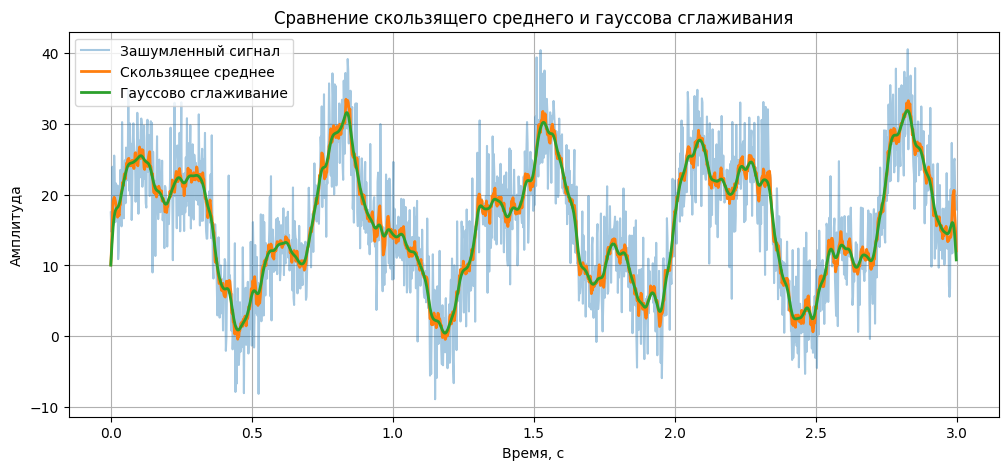

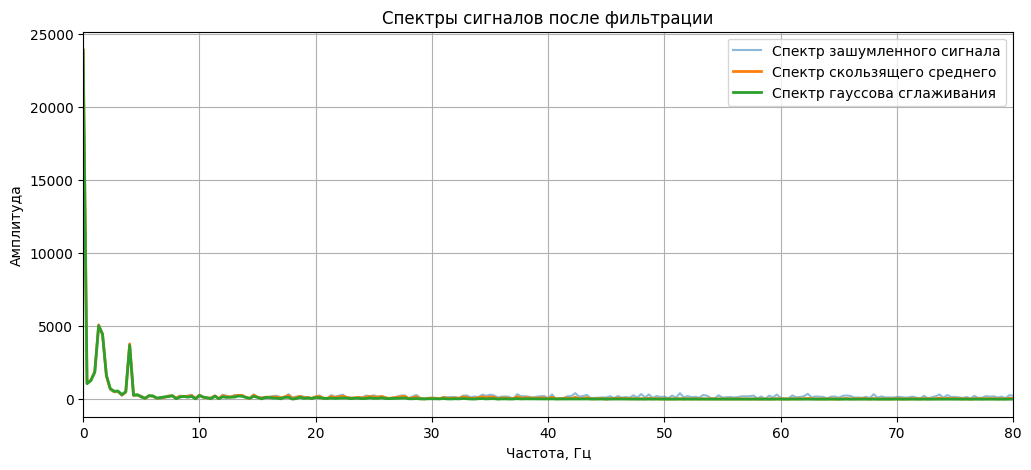

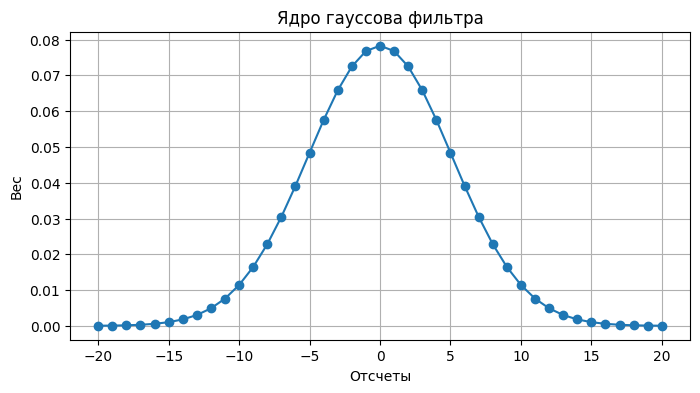

In [4]:
def gaussian_kernel(k, w):
    x = np.arange(-k, k + 1)
    g = np.exp(-(4 * np.log(2) * x**2) / (w**2))
    g = g / np.sum(g)
    return g


k_gauss = 20
w = 12

gauss_kernel = gaussian_kernel(k_gauss, w)
gauss_filtered_signal = np.convolve(noisy_signal, gauss_kernel, mode="same")

mean_filtered_signal = filtered_signal

spectrum_gauss = np.abs(np.fft.rfft(gauss_filtered_signal))
spectrum_mean = np.abs(np.fft.rfft(mean_filtered_signal))

plt.figure(figsize=(12, 5))
plt.plot(t, noisy_signal, label="Зашумленный сигнал", alpha=0.4)
plt.plot(t, mean_filtered_signal, label="Скользящее среднее", linewidth=2)
plt.plot(t, gauss_filtered_signal, label="Гауссово сглаживание", linewidth=2)
plt.title("Сравнение скользящего среднего и гауссова сглаживания")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(freqs, spectrum_noisy, label="Спектр зашумленного сигнала", alpha=0.5)
plt.plot(freqs, spectrum_mean, label="Спектр скользящего среднего", linewidth=2)
plt.plot(freqs, spectrum_gauss, label="Спектр гауссова сглаживания", linewidth=2)
plt.xlim(0, 80)
plt.title("Спектры сигналов после фильтрации")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(-k_gauss, k_gauss + 1), gauss_kernel, marker="o")
plt.title("Ядро гауссова фильтра")
plt.xlabel("Отсчеты")
plt.ylabel("Вес")
plt.grid(True)
plt.show()

### Задание 3

Нужно применить гауссово сглаживание к сигналу, который состоит из всплесков пиков.

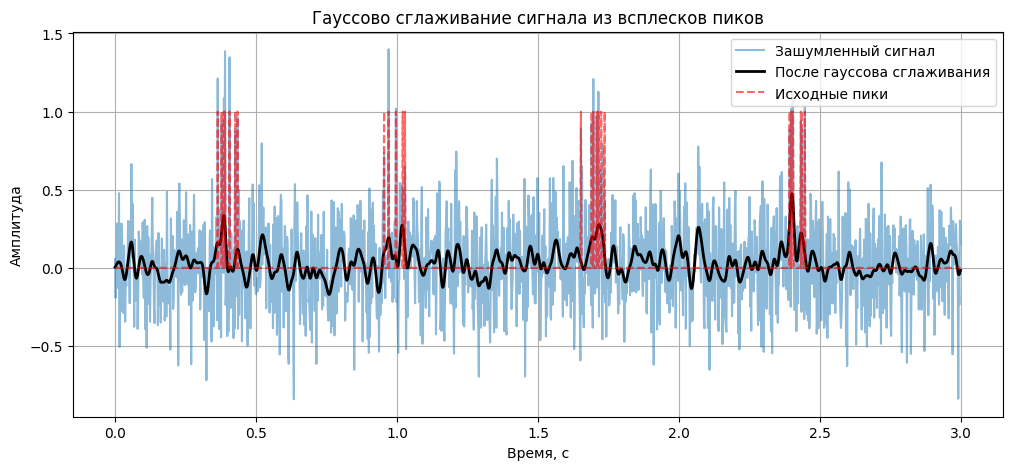

In [5]:
fs3 = 500
T3 = 3.0
t3 = np.linspace(0, T3, int(fs3 * T3), endpoint=False)

signal3 = np.zeros_like(t3)

np.random.seed(42)

burst_centers = [0.4, 1.0, 1.7, 2.4]
samples_per_sec = fs3

for center in burst_centers:
    center_idx = int(center * samples_per_sec)
    n_peaks = np.random.randint(4, 9)
    offsets = np.random.randint(-25, 26, size=n_peaks)
    peak_indices = center_idx + offsets
    peak_indices = peak_indices[(peak_indices >= 0) & (peak_indices < len(signal3))]
    signal3[peak_indices] = 1.0

noise3 = 0.25 * np.random.randn(len(signal3))
noisy_signal3 = signal3 + noise3

k3 = 12
w3 = 8
gauss_kernel3 = gaussian_kernel(k3, w3)
filtered_signal3 = np.convolve(noisy_signal3, gauss_kernel3, mode="same")

plt.figure(figsize=(12, 5))
plt.plot(t3, noisy_signal3, label="Зашумленный сигнал", alpha=0.5)
plt.plot(t3, filtered_signal3, label="После гауссова сглаживания", linewidth=2, color="black")
plt.plot(t3, signal3, label="Исходные пики", linestyle="--", linewidth=1.5, alpha=0.6, color="red")
plt.title("Гауссово сглаживание сигнала из всплесков пиков")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

### Задание 4

Нужно реализовать медианный фильтр для очистки сигнала от случайных всплесков.


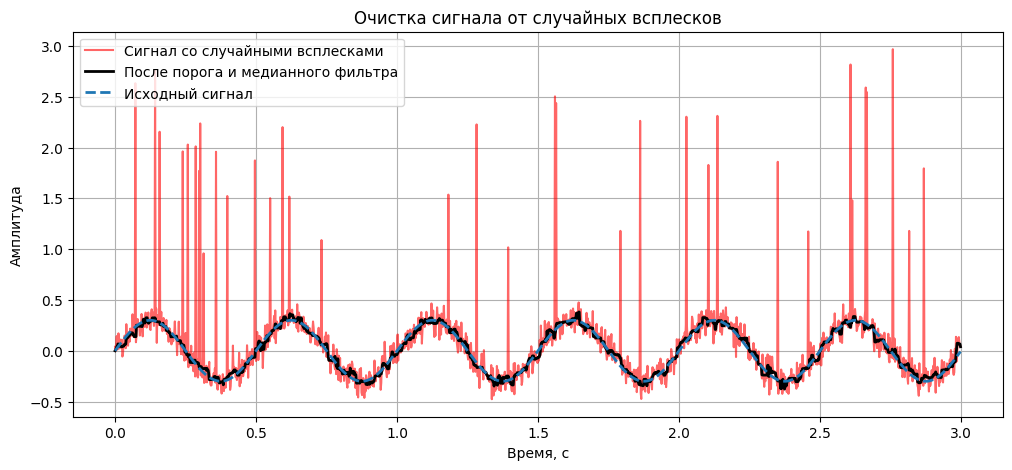

In [6]:

fs4 = 500
T4 = 3.0
t4 = np.linspace(0, T4, int(fs4 * T4), endpoint=False)

np.random.seed(42)

signal4 = 0.3 * np.sin(2 * np.pi * 2 * t4)

noise4 = 0.08 * np.random.randn(len(t4))
noisy_signal4 = signal4 + noise4

n_spikes = 35
spike_indices = np.random.choice(len(t4), size=n_spikes, replace=False)
spike_amplitudes = np.random.uniform(1.0, 3.0, size=n_spikes)

signal_with_spikes4 = noisy_signal4.copy()
signal_with_spikes4[spike_indices] += spike_amplitudes

threshold = 0.9

threshold_cleaned4 = signal_with_spikes4.copy()
bad_points = threshold_cleaned4 > threshold
threshold_cleaned4[bad_points] = np.median(threshold_cleaned4)

median_filtered4 = medfilt(threshold_cleaned4, kernel_size=9)

plt.figure(figsize=(12, 5))
plt.plot(t4, signal_with_spikes4, label="Сигнал со случайными всплесками", alpha=0.6, color="red")
plt.plot(t4, median_filtered4, label="После порога и медианного фильтра", linewidth=2, color="black")
plt.plot(t4, signal4, label="Исходный сигнал", linestyle="--", linewidth=2)
plt.title("Очистка сигнала от случайных всплесков")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

### Задание 5

Нужно удалить тренд из сигнала с помощью полиномиальной аппроксимации.


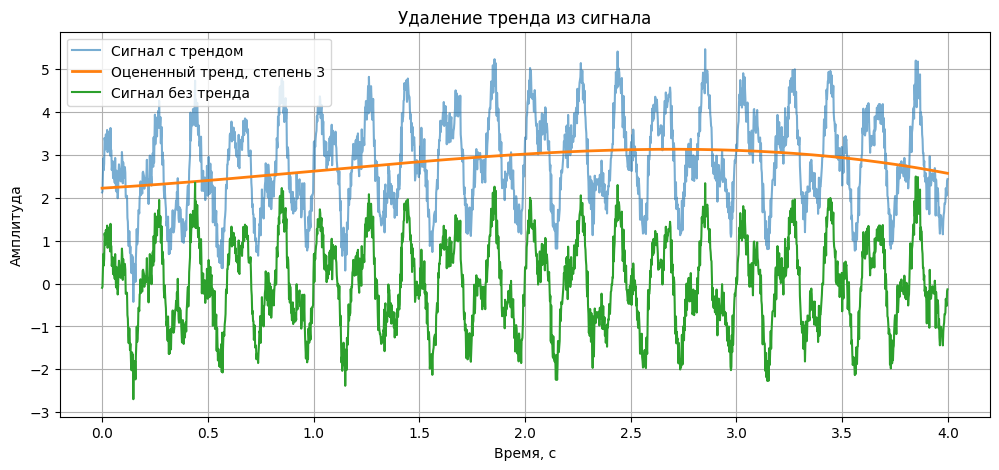

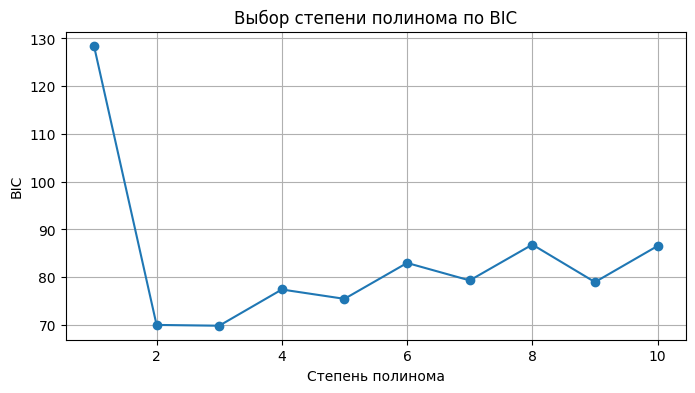

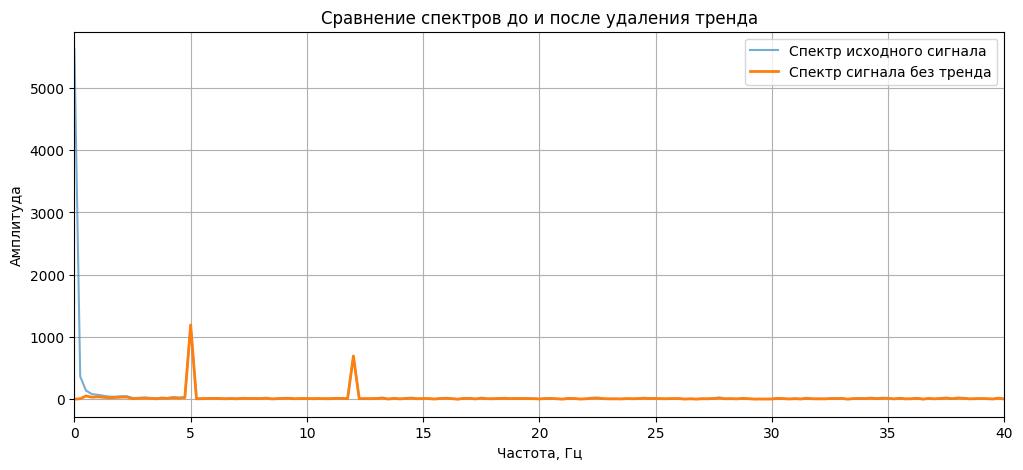

In [7]:
fs5 = 500
T5 = 4.0
t5 = np.linspace(0, T5, int(fs5 * T5), endpoint=False)

np.random.seed(42)

useful_signal5 = (
    1.2 * np.sin(2 * np.pi * 5 * t5) +
    0.7 * np.sin(2 * np.pi * 12 * t5)
)

trend5 = 0.8 * t5 - 0.15 * t5**2 + 2.0
noise5 = 0.25 * np.random.randn(len(t5))

signal_with_trend5 = useful_signal5 + trend5 + noise5

degrees = np.arange(1, 11)
bic_values = []

n = len(t5)

for degree in degrees:
    coeffs = np.polyfit(t5, signal_with_trend5, degree)
    fitted_trend = np.polyval(coeffs, t5)
    residuals = signal_with_trend5 - fitted_trend
    
    rss = np.sum(residuals**2)
    k = degree + 1
    
    bic = n * np.log(rss / n) + k * np.log(n)
    bic_values.append(bic)

best_degree = degrees[np.argmin(bic_values)]

best_coeffs = np.polyfit(t5, signal_with_trend5, best_degree)
estimated_trend5 = np.polyval(best_coeffs, t5)

detrended_signal5 = signal_with_trend5 - estimated_trend5

freqs5 = np.fft.rfftfreq(len(t5), d=1/fs5)
spectrum_original5 = np.abs(np.fft.rfft(signal_with_trend5))
spectrum_detrended5 = np.abs(np.fft.rfft(detrended_signal5))

plt.figure(figsize=(12, 5))
plt.plot(t5, signal_with_trend5, label="Сигнал с трендом", alpha=0.6)
plt.plot(t5, estimated_trend5, label=f"Оцененный тренд, степень {best_degree}", linewidth=2)
plt.plot(t5, detrended_signal5, label="Сигнал без тренда", linewidth=1.5)
plt.title("Удаление тренда из сигнала")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(degrees, bic_values, marker="o")
plt.title("Выбор степени полинома по BIC")
plt.xlabel("Степень полинома")
plt.ylabel("BIC")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(freqs5, spectrum_original5, label="Спектр исходного сигнала", alpha=0.6)
plt.plot(freqs5, spectrum_detrended5, label="Спектр сигнала без тренда", linewidth=2)
plt.xlim(0, 40)
plt.title("Сравнение спектров до и после удаления тренда")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

### Очистка ЭЭГ от артефактов с помощью регрессии

В этом задании нужно очистить сигнал ЭЭГ от артефакта ЭОГ с помощью линейной регрессии.

In [8]:
import scipy.io as sio
from scipy.signal import spectrogram

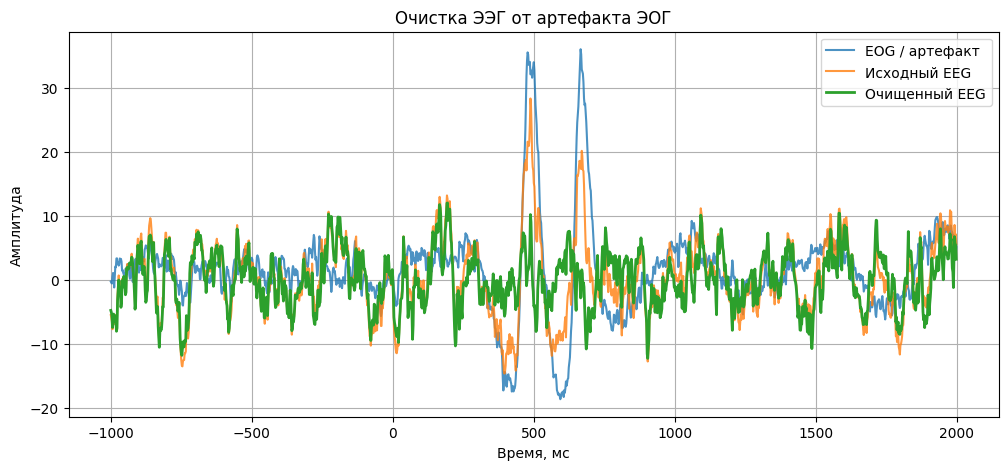

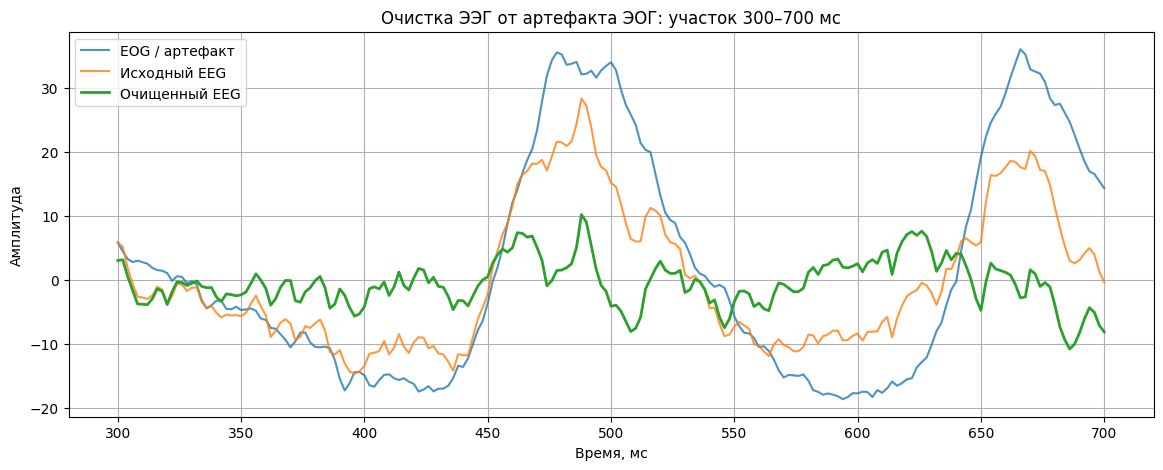

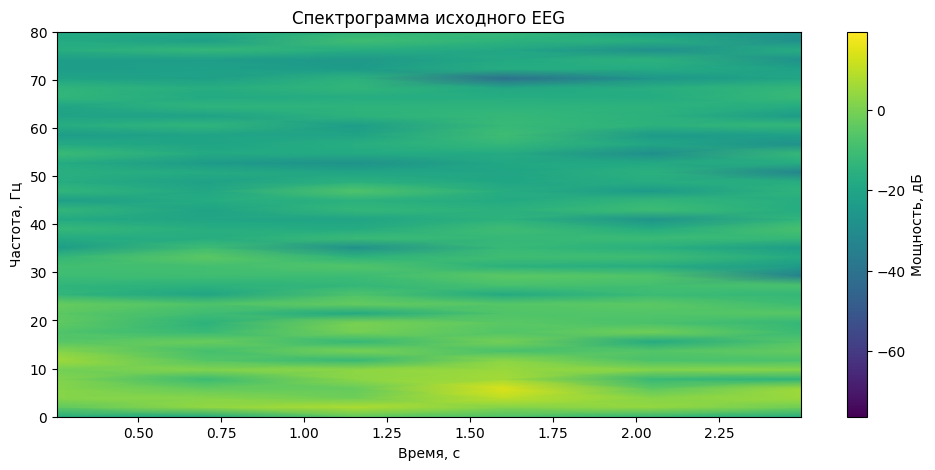

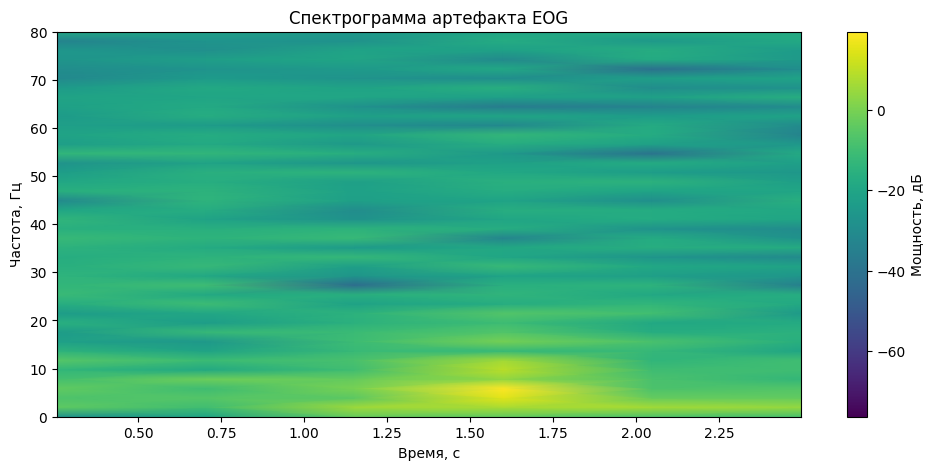

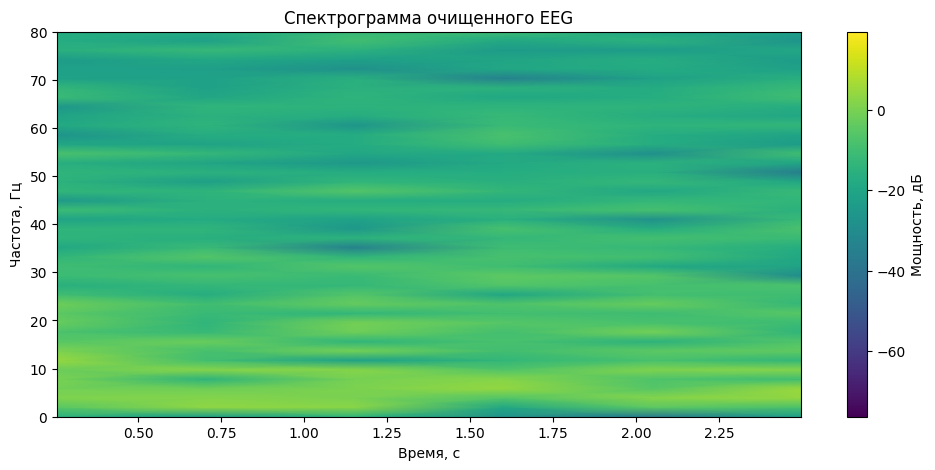

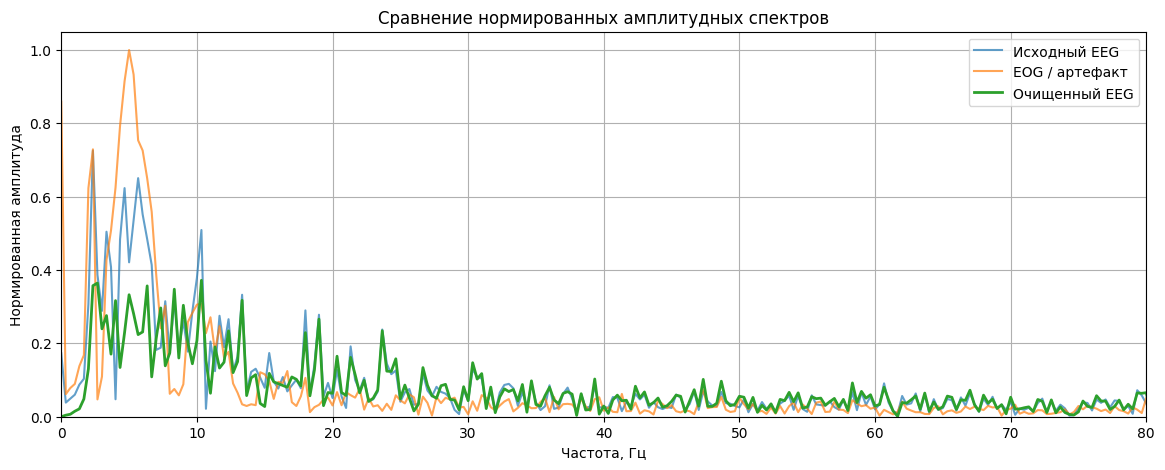

In [10]:
matdat = sio.loadmat("templateProjection.mat")

EEGdat = np.asarray(matdat["EEGdat"])
eyedat = np.asarray(matdat["eyedat"])
timevec = np.squeeze(matdat["timevec"])

if EEGdat.shape[0] != len(timevec):
    EEGdat = EEGdat.T

if eyedat.shape[0] != len(timevec):
    eyedat = eyedat.T

dt = np.median(np.diff(timevec)) / 1000
fs_eeg = 1 / dt

clean_EEG = np.zeros_like(EEGdat)

for trial in range(EEGdat.shape[1]):
    y = EEGdat[:, trial]
    eog = eyedat[:, trial]

    X = np.column_stack([
        np.ones(len(eog)),
        eog
    ])

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    artifact_estimate = X @ beta

    clean_EEG[:, trial] = y - artifact_estimate

trial_idx = 0

eeg_signal = EEGdat[:, trial_idx]
eog_signal = eyedat[:, trial_idx]
clean_signal = clean_EEG[:, trial_idx]

plt.figure(figsize=(12, 5))
plt.plot(timevec, eog_signal, label="EOG / артефакт", alpha=0.8)
plt.plot(timevec, eeg_signal, label="Исходный EEG", alpha=0.8)
plt.plot(timevec, clean_signal, label="Очищенный EEG", linewidth=2)
plt.title("Очистка ЭЭГ от артефакта ЭОГ")
plt.xlabel("Время, мс")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()


mask_zoom = (timevec >= 300) & (timevec <= 700)

plt.figure(figsize=(14, 5))

plt.plot(timevec[mask_zoom], eog_signal[mask_zoom], label="EOG / артефакт", alpha=0.8)
plt.plot(timevec[mask_zoom], eeg_signal[mask_zoom], label="Исходный EEG", alpha=0.8)
plt.plot(timevec[mask_zoom], clean_signal[mask_zoom], label="Очищенный EEG", linewidth=2)

plt.title("Очистка ЭЭГ от артефакта ЭОГ: участок 300–700 мс")
plt.xlabel("Время, мс")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()


f_eeg, t_eeg, Sxx_eeg = spectrogram(eeg_signal, fs=fs_eeg)
f_eog, t_eog, Sxx_eog = spectrogram(eog_signal, fs=fs_eeg)
f_clean, t_clean, Sxx_clean = spectrogram(clean_signal, fs=fs_eeg)

Sxx_eeg_db = 10 * np.log10(Sxx_eeg + 1e-12)
Sxx_eog_db = 10 * np.log10(Sxx_eog + 1e-12)
Sxx_clean_db = 10 * np.log10(Sxx_clean + 1e-12)

vmin = min(Sxx_eeg_db.min(), Sxx_eog_db.min(), Sxx_clean_db.min())
vmax = max(Sxx_eeg_db.max(), Sxx_eog_db.max(), Sxx_clean_db.max())

plt.figure(figsize=(12, 5))
plt.pcolormesh(t_eeg, f_eeg, Sxx_eeg_db, shading="gouraud", vmin=vmin, vmax=vmax)
plt.title("Спектрограмма исходного EEG")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.ylim(0, 80)
plt.colorbar(label="Мощность, дБ")
plt.show()

plt.figure(figsize=(12, 5))
plt.pcolormesh(t_eog, f_eog, Sxx_eog_db, shading="gouraud", vmin=vmin, vmax=vmax)
plt.title("Спектрограмма артефакта EOG")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.ylim(0, 80)
plt.colorbar(label="Мощность, дБ")
plt.show()

plt.figure(figsize=(12, 5))
plt.pcolormesh(t_clean, f_clean, Sxx_clean_db, shading="gouraud", vmin=vmin, vmax=vmax)
plt.title("Спектрограмма очищенного EEG")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.ylim(0, 80)
plt.colorbar(label="Мощность, дБ")
plt.show()


freqs_eeg = np.fft.rfftfreq(len(timevec), d=1/fs_eeg)

spectrum_eeg = np.abs(np.fft.rfft(eeg_signal))
spectrum_eog = np.abs(np.fft.rfft(eog_signal))
spectrum_clean = np.abs(np.fft.rfft(clean_signal))

max_value = max(
    spectrum_eeg.max(),
    spectrum_eog.max(),
    spectrum_clean.max()
)

spectrum_eeg_norm = spectrum_eeg / max_value
spectrum_eog_norm = spectrum_eog / max_value
spectrum_clean_norm = spectrum_clean / max_value

plt.figure(figsize=(14, 5))

plt.plot(freqs_eeg, spectrum_eeg_norm, label="Исходный EEG", alpha=0.7)
plt.plot(freqs_eeg, spectrum_eog_norm, label="EOG / артефакт", alpha=0.7)
plt.plot(freqs_eeg, spectrum_clean_norm, label="Очищенный EEG", linewidth=2)

plt.title("Сравнение нормированных амплитудных спектров")
plt.xlabel("Частота, Гц")
plt.ylabel("Нормированная амплитуда")
plt.xlim(0, 80)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()